<a href="https://colab.research.google.com/github/FelipeConza/IntroduccionSistemasInformacion/blob/main/StratifyIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stratify IA
**Transformación Digital Empresarial (ISID223)** · Proyecto final

Sistema de consola en **Python con Programación Orientada a Objetos** y persistencia en archivos **CSV**. Integra los módulos **ERP** (finanzas), **SCM** (inventario y órdenes de compra automáticas) y **CRM** (riesgo de deserción), con **segmentación RFM** y un **dashboard gerencial**.

Dataset base: `gym_churn_us.csv` (4000 miembros).

> **Cómo usarlo:** ejecuta las celdas **de arriba hacia abajo** y al final corre la celda **▶ Ejecutar el gestor**. Responde los menús escribiendo el número de la opción y presionando *Enter*.

## Paso previo: cargar el dataset
Sube `gym_churn_us.csv` al entorno. Si no lo subes, el programa usa datos de ejemplo.

> En Colab el almacenamiento se borra al cerrar la sesión. Para conservar los CSV entre sesiones, puedes montar Google Drive y trabajar dentro de una carpeta de Drive.

In [15]:
import os
if not os.path.exists('gym_churn_us.csv'):
    try:
        from google.colab import files
        print('Sube el archivo gym_churn_us.csv:')
        files.upload()
    except Exception:
        print('Coloca gym_churn_us.csv junto al notebook (se usarán datos de ejemplo si falta).')
else:
    print('Dataset encontrado ✓')

Dataset encontrado ✓


##  Instalación de dependencias
Colab ya trae estas librerías; ejecuta por si acaso.

In [16]:
import sys, subprocess
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn']:
    try:
        __import__('sklearn' if pkg == 'scikit-learn' else pkg)
    except Exception:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('Dependencias listas ✓')

Dependencias listas ✓


##  Importaciones
Librerías estándar de datos y visualización; el modelo de *churn* usa scikit-learn (opcional).

In [17]:
# -*- coding: utf-8 -*-
"""
GESTOR DE GIMNASIO — Sistema de consola para Google Colab (versión POO).
Programación Orientada a Objetos + persistencia en archivos CSV planos.

Clases de dominio:
    Producto, Cliente, Venta, OrdenCompra
Módulos (clases de servicio):
    ERP  -> finanzas / caja (asiento contable con cada venta)
    SCM  -> inventario + Orden de Compra automática al proveedor
    CRM  -> riesgo de deserción por inactividad (aísla el registro) + modelo predictivo
    Gimnasio (sistema principal / Core Business) -> orquesta todo
Analítica:
    RFM (Recencia, Frecuencia, Monto)  y  Dashboard gerencial (tema oscuro, KPIs dorados)
"""

import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe
from datetime import datetime, timedelta

# Modelo predictivo opcional para el CRM (extra, si scikit-learn está disponible).
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

### 1. Configuración
Rutas de los archivos CSV (persistencia), reglas de negocio (umbral de stock, días de inactividad del CRM, proveedor) y la **paleta oscura con acentos dorados** del dashboard.

In [18]:
ARCHIVO_MIEMBROS     = "gym_churn_us.csv"
ARCHIVO_INVENTARIO   = "inventario.csv"
ARCHIVO_TRANSACCIONES = "transacciones.csv"   # histórico de ventas (ERP / RFM / temporal)
ARCHIVO_ORDENES      = "ordenes_compra.csv"    # órdenes de compra automáticas (SCM)
ARCHIVO_CRM_RIESGO   = "crm_clientes_riesgo.csv"  # registros aislados por el CRM
ARCHIVO_PANEL        = "panel_gimnasio.png"

ANCHO = 58  # ancho de las reglas de la consola

# Si en tu Colab la limpieza de pantalla llegara a bloquear el menú, pon esto en False.
USAR_LIMPIEZA = True

# Reglas de negocio
UMBRAL_STOCK            = 5     # SCM: menos de esto = stock bajo -> orden de compra
UMBRAL_INACTIVIDAD_DIAS = 30    # CRM: sin compras por más de X días = en riesgo
PROVEEDOR               = "Distribuidora FitSupply"
DIAS_HISTORICO          = 90    # ventana del histórico de transacciones simulado

# Nivel estándar (stock objetivo) de cada producto. Al recibir una orden de
# compra, el inventario se repone HASTA este nivel (nunca por encima).
NIVEL_ESTANDAR = {
    "Agua 500ml": 20,
    "Barra de proteína": 15,
    "Bebida isotónica": 10,
    "Pre-entreno": 8,
}

# Paleta OSCURA con acentos DORADOS (basada en el logo Stratify IA)
BG    = "#0e1013"   # carbón casi negro
PANEL = "#161922"   # panel
CARD  = "#1e222c"   # tarjeta KPI
INK   = "#f3ecdd"   # texto cálido (marfil)
MUTED = "#9a9488"   # texto secundario (gris cálido)
GRID  = "#2a2e39"   # rejilla tenue
# Familia dorada (el dorado principal coincide con las barras del logo)
GOLD   = "#f8c854"  # dorado principal
GOLDL  = "#ffe08a"  # dorado claro
GOLDD  = "#d1a02f"  # dorado profundo
CHAMP  = "#e9dbb0"  # champaña
AMBER  = "#f0a63a"  # ámbar
BRONZE = "#bd9142"  # bronce
TERRA  = "#d47a5a"  # terracota (para valores negativos)
# Alias usados por los gráficos (mapeados a la paleta dorada)
N_CYAN   = GOLD
N_GREEN  = GOLDL
N_PINK   = TERRA
N_PURPLE = BRONZE
N_YELLOW = GOLD
N_ORANGE = AMBER
N_RED    = TERRA
PRIM  = GOLD
SAGE  = GOLDL


COLUMNAS_ORIGINALES = [
    "gender", "Near_Location", "Partner", "Promo_friends", "Phone",
    "Contract_period", "Group_visits", "Age", "Avg_additional_charges_total",
    "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total",
    "Avg_class_frequency_current_month", "Churn",
]
FEATURES_MODELO = [
    "gender", "Near_Location", "Partner", "Promo_friends", "Phone",
    "Contract_period", "Group_visits", "Age", "Avg_additional_charges_total",
    "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
]

### 2. Utilidades de consola
Funciones para imprimir menús y tablas alineadas. **Toda** la lectura de teclado pasa por `_leer()`, que da tiempo a Colab a redibujar y evita que `input()` se congele tras limpiar la pantalla.

In [19]:
def _regla(caracter="─", ancho=ANCHO):
    print("  " + caracter * ancho)

def _titulo(texto, doble=False):
    print("\n  " + texto.upper())
    _regla("═" if doble else "─")

def _kv(etiqueta, valor, ancho_etq=30):
    print(f"  {etiqueta:.<{ancho_etq}} {valor}")

def _item(num, texto):
    print(f"    [{num}]  {texto}")

def _ok(msg):   print(f"  ✓ {msg}")
def _warn(msg): print(f"  ⚠ {msg}")
def _err(msg):  print(f"  ✗ {msg}")
def _info(msg): print(f"  · {msg}")


def _limpiar():
    """Limpia la pantalla para no acumular información previa.
    En Colab usa clear_output; en terminal, 'clear'/'cls'. Desactivable con USAR_LIMPIEZA."""
    if not USAR_LIMPIEZA:
        print("\n")
        return
    try:
        from IPython.display import clear_output
        clear_output(wait=True)
    except Exception:
        os.system("cls" if os.name == "nt" else "clear")


def _leer(prompt=""):
    """Lee entrada dando tiempo a Colab a renderizar (evita que input() se cuelgue
    tras limpiar la pantalla, un problema de temporización conocido en Colab)."""
    try:
        sys.stdout.flush()
    except Exception:
        pass
    time.sleep(0.15)
    return input(prompt)


def _pausa(msg="Presiona Enter para continuar..."):
    try:
        _leer(f"\n  {msg}")
    except EOFError:
        pass


def _pedir_entero(msg, minimo, maximo, defecto):
    while True:
        extra = f" [{defecto}]" if defecto is not None else ""
        s = _leer(f"  {msg}{extra} > ").strip()
        if s == "" and defecto is not None:
            return defecto
        if s == "":
            _info("Ingresa un valor.");  continue
        try:
            v = int(s)
        except ValueError:
            _info("Debe ser un número entero.");  continue
        if v < minimo or v > maximo:
            _info(f"Debe estar entre {minimo} y {maximo}.");  continue
        return v


def _pedir_opcion_lista(msg, opciones, defecto):
    while True:
        s = _leer(f"  {msg} {opciones} [{defecto}] > ").strip()
        if s == "":
            return defecto
        try:
            v = int(s)
        except ValueError:
            _info("Número inválido.");  continue
        if v in opciones:
            return v
        _info(f"Elige una de: {opciones}")

### 3. Estilo del dashboard
Parámetros de Matplotlib, tarjetas KPI con *glow* y ejes con rejilla tenue para el tema oscuro.

In [20]:
def _aplicar_estilo_visual():
    plt.rcParams.update({
        "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
        "font.family": "DejaVu Sans", "font.size": 10,
        "text.color": INK, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
        "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 110,
    })


def _glow(color, capas=3, base=2.0):
    efectos = [pe.Stroke(linewidth=base * i, foreground=color, alpha=0.10)
               for i in range(capas, 0, -1)]
    efectos.append(pe.Normal())
    return efectos


def _estilo_ax(ax, titulo="", eje="y"):
    ax.set_facecolor(PANEL)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8.5, length=0)
    if eje == "y":
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    elif eje == "x":
        ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    if titulo:
        ax.set_title(titulo, fontsize=10.5, fontweight="bold", color=INK, loc="left", pad=8)


def _kpi_card(ax, valor, etiqueta, color):
    ax.set_facecolor(CARD)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]);  ax.set_yticks([])
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
    ax.add_patch(Rectangle((0, 0.87), 1, 0.13, color=color, ec="none"))
    num = ax.text(0.5, 0.50, str(valor), ha="center", va="center",
                  fontsize=18, fontweight="bold", color=color)
    num.set_path_effects(_glow(color))
    ax.text(0.5, 0.15, etiqueta, ha="center", va="center", fontsize=8, color=MUTED)


def _vacio_ax(ax, titulo, mensaje):
    ax.set_facecolor(PANEL)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]);  ax.set_yticks([])
    ax.text(0.5, 0.5, mensaje, ha="center", va="center", color=MUTED, fontsize=9.5)
    ax.set_title(titulo, fontsize=10.5, fontweight="bold", color=INK, loc="left", pad=8)

### 4. Clases de dominio (POO)
`Producto`, `Cliente`, `Venta` y `OrdenCompra`. Cada clase encapsula sus datos y su comportamiento (p. ej. `Producto.stock_bajo()`, `Cliente.registrar_asistencia()`).

In [21]:
class Producto:
    """Producto de la tienda del gimnasio."""
    def __init__(self, nombre, precio, stock, estandar=None):
        self.nombre = str(nombre)
        self.precio = float(precio)
        self.stock = int(stock)
        # nivel estándar (stock objetivo al reponer). Si no se indica, es el stock inicial.
        self.estandar = int(estandar) if estandar is not None else int(stock)

    def hay_stock(self, cantidad):
        return self.stock >= cantidad

    def descontar(self, cantidad):
        self.stock -= int(cantidad)

    def stock_bajo(self, umbral=UMBRAL_STOCK):
        return self.stock < umbral

    def faltante_estandar(self):
        """Unidades que faltan para llegar al nivel estándar."""
        return max(self.estandar - self.stock, 0)

    def reponer_a_estandar(self):
        """Repone el stock exactamente hasta el nivel estándar (no lo supera)."""
        self.stock = self.estandar

    def to_dict(self):
        return {"producto": self.nombre, "precio": round(self.precio, 2),
                "stock": self.stock, "estandar": self.estandar}


class Cliente:
    """Miembro del gimnasio. Guarda los datos del dataset + los campos del sistema."""
    def __init__(self, datos: dict):
        self.member_id = int(datos["member_id"])
        self.nombre = str(datos.get("nombre", f"Miembro_{self.member_id}"))
        self.descripcion = str(datos.get("descripcion", ""))
        self.activo = int(datos.get("activo", 1))
        self.asistencias_manuales = int(datos.get("asistencias_manuales", 0))
        self.gasto_tienda = float(datos.get("gasto_tienda", 0.0))
        self.en_riesgo_crm = int(datos.get("en_riesgo_crm", 0))
        # Datos originales del dataset (features)
        self.datos = {c: datos.get(c, 0) for c in COLUMNAS_ORIGINALES}
        self.dias_inactivo = None  # lo calcula el CRM (None=aún no; -1=nunca compró)

    # --- accesos de conveniencia ---
    @property
    def edad(self):
        return int(self.datos["Age"])

    @property
    def genero_texto(self):
        return "Masculino" if int(self.datos["gender"]) == 1 else "Femenino"

    def esta_activo(self):
        return self.activo == 1

    def registrar_asistencia(self):
        self.asistencias_manuales += 1
        nueva = min(float(self.datos["Avg_class_frequency_current_month"]) + 0.1, 7.0)
        self.datos["Avg_class_frequency_current_month"] = round(nueva, 2)
        return nueva

    def descripcion_automatica(self):
        life = int(self.datos.get("Lifetime", 0) or 0)
        freq = float(self.datos.get("Avg_class_frequency_current_month", 0) or 0)
        contrato = int(self.datos.get("Contract_period", 0) or 0)
        return (f"Miembro de {life} mes(es) de antigüedad, {self.edad} años. "
                f"Asiste ~{freq:.1f} veces/semana este mes. Contrato de {contrato} mes(es).")

    def to_row(self):
        fila = {
            "member_id": self.member_id, "nombre": self.nombre,
            "descripcion": self.descripcion, "activo": self.activo,
            "asistencias_manuales": self.asistencias_manuales,
            "gasto_tienda": round(self.gasto_tienda, 2),
            "en_riesgo_crm": self.en_riesgo_crm,
        }
        fila.update(self.datos)
        return fila


class Venta:
    """Transacción de venta en la tienda (registro del histórico)."""
    def __init__(self, fecha, member_id, producto, cantidad, monto):
        self.fecha = str(fecha)
        self.member_id = int(member_id)
        self.producto = str(producto)
        self.cantidad = int(cantidad)
        self.monto = round(float(monto), 2)

    def to_dict(self):
        return {"fecha": self.fecha, "member_id": self.member_id,
                "producto": self.producto, "cantidad": self.cantidad, "monto": self.monto}


class OrdenCompra:
    """Orden de compra automática que el SCM emite al proveedor cuando baja el stock."""
    def __init__(self, orden_id, fecha, producto, cantidad,
                 proveedor=PROVEEDOR, estado="Pendiente"):
        self.id = int(orden_id)
        self.fecha = str(fecha)
        self.producto = str(producto)
        self.cantidad = int(cantidad)
        self.proveedor = str(proveedor)
        self.estado = str(estado)

    def to_dict(self):
        return {"orden_id": self.id, "fecha": self.fecha, "producto": self.producto,
                "cantidad": self.cantidad, "proveedor": self.proveedor, "estado": self.estado}

### 5. Módulo ERP
Lleva el **libro de ventas (caja)**. Cada venta del sistema principal genera automáticamente un asiento (`registrar_venta`).

In [22]:
class ERP:
    """Módulo financiero: lleva el libro de ventas (caja). Cada venta = un asiento."""
    COLS = ["fecha", "member_id", "producto", "cantidad", "monto"]

    def __init__(self, archivo=ARCHIVO_TRANSACCIONES):
        self.archivo = archivo
        self.transacciones = self._cargar()

    def _cargar(self):
        if os.path.exists(self.archivo):
            df = pd.read_csv(self.archivo)
            for c in self.COLS:
                if c not in df.columns:
                    df[c] = "" if c == "fecha" else 0
            return df[self.COLS]
        return pd.DataFrame(columns=self.COLS)

    def guardar(self):
        self.transacciones.to_csv(self.archivo, index=False)

    def registrar_venta(self, venta: Venta):
        """Integración Core -> ERP: registra el asiento y actualiza la caja."""
        self.transacciones = pd.concat(
            [self.transacciones, pd.DataFrame([venta.to_dict()])], ignore_index=True)
        self.guardar()

    def caja_tienda(self):
        return float(self.transacciones["monto"].sum()) if len(self.transacciones) else 0.0

    def ingresos_por_producto(self):
        if not len(self.transacciones):
            return pd.Series(dtype=float)
        return self.transacciones.groupby("producto")["monto"].sum().sort_values(ascending=False)

    def ventas_por_semana(self):
        if not len(self.transacciones):
            return pd.Series(dtype=float)
        t = self.transacciones.copy()
        t["fecha"] = pd.to_datetime(t["fecha"], errors="coerce")
        t = t.dropna(subset=["fecha"])
        return t.set_index("fecha").resample("W")["monto"].sum()

### 6. Módulo SCM
Gestiona el inventario y **genera una Orden de Compra automática** al proveedor cuando una venta deja el stock por debajo del umbral (`revisar_reponer`).

In [23]:
class SCM:
    """Cadena de suministro: inventario y generación automática de Órdenes de Compra."""
    COLS_ORD = ["orden_id", "fecha", "producto", "cantidad", "proveedor", "estado"]

    def __init__(self, archivo_inv=ARCHIVO_INVENTARIO, archivo_ord=ARCHIVO_ORDENES):
        self.archivo_inv = archivo_inv
        self.archivo_ord = archivo_ord
        self.productos = self._cargar_inventario()
        self.ordenes = self._cargar_ordenes()

    def _cargar_inventario(self):
        if os.path.exists(self.archivo_inv):
            inv = pd.read_csv(self.archivo_inv)
        else:
            inv = pd.DataFrame({
                "producto": ["Agua 500ml", "Barra de proteína", "Bebida isotónica", "Pre-entreno"],
                "precio":   [1.50, 3.00, 2.50, 8.00],
                "stock":    [20, 15, 10, 8],
            })
            inv["estandar"] = inv["stock"]
            inv.to_csv(self.archivo_inv, index=False)
        tiene_estandar = "estandar" in inv.columns
        productos = []
        for _, r in inv.iterrows():
            nombre = r["producto"]
            if tiene_estandar and not pd.isna(r["estandar"]):
                est = int(r["estandar"])
            else:
                est = int(NIVEL_ESTANDAR.get(nombre, r["stock"]))
            productos.append(Producto(nombre, r["precio"], r["stock"], est))
        return productos

    def guardar_inventario(self):
        pd.DataFrame([p.to_dict() for p in self.productos]).to_csv(self.archivo_inv, index=False)

    def _cargar_ordenes(self):
        if os.path.exists(self.archivo_ord):
            df = pd.read_csv(self.archivo_ord)
            return [OrdenCompra(r["orden_id"], r["fecha"], r["producto"], r["cantidad"],
                                r.get("proveedor", PROVEEDOR), r.get("estado", "Pendiente"))
                    for _, r in df.iterrows()]
        return []

    def guardar_ordenes(self):
        if self.ordenes:
            pd.DataFrame([o.to_dict() for o in self.ordenes]).to_csv(self.archivo_ord, index=False)
        else:
            pd.DataFrame(columns=self.COLS_ORD).to_csv(self.archivo_ord, index=False)

    def buscar(self, nombre):
        for p in self.productos:
            if p.nombre == nombre:
                return p
        return None

    def disponibles(self):
        return [p for p in self.productos if p.stock > 0]

    def vender(self, nombre, cantidad):
        """Descuenta stock de un producto (lo dispara una venta del Core)."""
        p = self.buscar(nombre)
        if p and p.hay_stock(cantidad):
            p.descontar(cantidad)
            self.guardar_inventario()
        return p

    def _hay_orden_pendiente(self, nombre):
        return any(o.producto == nombre and o.estado == "Pendiente" for o in self.ordenes)

    def revisar_reponer(self, producto, fecha):
        """Integración Core -> SCM: si el stock quedó bajo y no hay orden pendiente,
        genera una Orden de Compra por las unidades que faltan para el estándar."""
        faltante = producto.faltante_estandar()
        if producto.stock_bajo() and faltante > 0 and not self._hay_orden_pendiente(producto.nombre):
            nuevo_id = (max([o.id for o in self.ordenes]) + 1) if self.ordenes else 1
            orden = OrdenCompra(nuevo_id, str(fecha), producto.nombre, faltante)
            self.ordenes.append(orden)
            self.guardar_ordenes()
            return orden
        return None

    def alertas(self):
        return [p for p in self.productos if p.stock_bajo()]

    def ordenes_pendientes(self):
        return [o for o in self.ordenes if o.estado == "Pendiente"]

    def recibir_orden(self, orden):
        """Marca una orden como recibida y repone el inventario hasta el estándar."""
        if orden.estado != "Pendiente":
            return None
        orden.estado = "Recibida"
        p = self.buscar(orden.producto)
        if p is not None:
            p.reponer_a_estandar()
        self.guardar_inventario()
        self.guardar_ordenes()
        return p

    def recibir_pendientes(self):
        """Recibe todas las órdenes pendientes: repone cada producto hasta su estándar."""
        recibidas = []
        for o in self.ordenes:
            if o.estado == "Pendiente":
                o.estado = "Recibida"
                p = self.buscar(o.producto)
                if p is not None:
                    p.reponer_a_estandar()
                recibidas.append(o)
        if recibidas:
            self.guardar_inventario()
            self.guardar_ordenes()
        return recibidas

    def unidades_totales(self):
        return int(sum(p.stock for p in self.productos))

### 7. Módulo CRM
Detecta por consulta automática a los clientes que **compraban y dejaron de hacerlo** (inactividad), **aísla** sus registros y dispara la alerta de riesgo. Incluye un modelo predictivo de *churn* (extra) y el algoritmo **RFM**.

In [24]:
class CRM:
    """Relación con el cliente: detecta inactividad (aísla registros), modelo de churn y RFM."""
    def __init__(self, umbral_dias=UMBRAL_INACTIVIDAD_DIAS):
        self.umbral = umbral_dias
        self.clf = None
        self.scaler = None
        self.modelo_ok = False
        self.aislados = []

    # --- modelo predictivo (extra) ---
    def entrenar_modelo(self, df):
        if not SKLEARN_OK:
            self.modelo_ok = False
            return
        try:
            X = df[FEATURES_MODELO].fillna(0).astype(float)
            y = df["Churn"].fillna(0).astype(int)
            if y.nunique() < 2:
                self.modelo_ok = False
                return
            self.scaler = StandardScaler().fit(X)
            self.clf = LogisticRegression(max_iter=1000).fit(self.scaler.transform(X), y)
            self.modelo_ok = True
        except Exception:
            self.modelo_ok = False

    def prob_baja_df(self, sub):
        if self.modelo_ok:
            X = sub[FEATURES_MODELO].fillna(0).astype(float)
            return pd.Series(self.clf.predict_proba(self.scaler.transform(X))[:, 1], index=sub.index)
        return sub.apply(self._heuristico, axis=1)

    @staticmethod
    def _heuristico(row):
        s = 0.0
        if int(row.get("Contract_period", 12) or 12) == 1: s += 2
        if float(row.get("Month_to_end_contract", 12) or 12) <= 1: s += 2
        fc = float(row.get("Avg_class_frequency_current_month", 0) or 0)
        if fc < 1: s += 2
        elif fc < 2: s += 1
        if float(row.get("Lifetime", 0) or 0) < 3: s += 2
        if int(row.get("Group_visits", 0) or 0) == 0: s += 1
        return min(s / 10.0, 1.0)

    @staticmethod
    def nivel_riesgo(p):
        if p >= 0.60: return "ALTO"
        if p >= 0.30: return "MEDIO"
        return "BAJO"

    # --- detección por INACTIVIDAD (requisito CRM) ---
    def detectar_inactivos(self, clientes, transacciones, hoy):
        """Consulta automática: clientes ACTIVOS sin compras en más de `umbral` días.
        Aísla su registro (marca en_riesgo_crm=1) y devuelve la lista de aislados."""
        ultima = {}
        if len(transacciones):
            t = transacciones.copy()
            t["fecha"] = pd.to_datetime(t["fecha"], errors="coerce")
            u = t.dropna(subset=["fecha"]).groupby("member_id")["fecha"].max()
            ultima = {int(k): v for k, v in u.items()}
        hoy_ts = pd.Timestamp(hoy)
        aislados = []
        for c in clientes:
            if not c.esta_activo():
                c.en_riesgo_crm = 0
                c.dias_inactivo = None
                continue
            f = ultima.get(c.member_id)
            # "En riesgo de deserción" = clientes que SÍ compraban y llevan
            # más de `umbral` días sin comprar (los que nunca compraron los
            # cubre el modelo predictivo, no la señal de inactividad).
            if f is not None:
                dias = (hoy_ts - f).days
                inactivo = dias > self.umbral
            else:
                dias = None
                inactivo = False
            c.en_riesgo_crm = 1 if inactivo else 0
            c.dias_inactivo = dias if inactivo else None
            if inactivo:
                aislados.append(c)
        self.aislados = aislados
        return aislados

    def exportar_aislados(self, archivo=ARCHIVO_CRM_RIESGO):
        filas = []
        for c in self.aislados:
            filas.append({"member_id": c.member_id, "nombre": c.nombre,
                          "dias_sin_comprar": c.dias_inactivo,
                          "gasto_historico": round(c.gasto_tienda, 2)})
        cols = ["member_id", "nombre", "dias_sin_comprar", "gasto_historico"]
        pd.DataFrame(filas, columns=cols).to_csv(archivo, index=False)

    # --- Segmentación RFM (Fase 3.1) ---
    def rfm(self, transacciones, hoy):
        """Calcula Recencia, Frecuencia y Monto por cliente y asigna un segmento."""
        if not len(transacciones):
            return pd.DataFrame(columns=["member_id", "recencia", "frecuencia",
                                         "monetario", "R", "F", "M", "segmento"])
        t = transacciones.copy()
        t["fecha"] = pd.to_datetime(t["fecha"], errors="coerce")
        t = t.dropna(subset=["fecha"])
        hoy_ts = pd.Timestamp(hoy)
        g = t.groupby("member_id").agg(
            recencia=("fecha", lambda s: (hoy_ts - s.max()).days),
            frecuencia=("fecha", "count"),
            monetario=("monto", "sum"),
        ).reset_index()
        try:
            g["R"] = pd.qcut(g["recencia"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
            g["F"] = pd.qcut(g["frecuencia"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
            g["M"] = pd.qcut(g["monetario"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
        except Exception:
            g["R"] = g["F"] = g["M"] = 2
        g["segmento"] = g.apply(self._segmento_rfm, axis=1)
        return g

    @staticmethod
    def _segmento_rfm(r):
        R, F, M = int(r["R"]), int(r["F"]), int(r["M"])
        if R >= 3 and F >= 3 and M >= 3: return "VIP"
        if R >= 3 and F >= 3:            return "Leales"
        if R >= 3 and F < 3:             return "Nuevos"
        if R < 3 and (F >= 3 or M >= 3): return "Recuperable"
        if R <= 2 and F <= 2:            return "En hibernación"
        return "Ocasional"

### 8. Sistema principal (Core)
La clase `Gimnasio` contiene a los clientes y **coordina** ERP, SCM y CRM. Aquí vive la integración: `registrar_venta()` descuenta stock (SCM), registra el ingreso (ERP), actualiza al cliente y repone si hace falta.

In [25]:
class Gimnasio:
    """Sistema central. Contiene a los clientes y coordina ERP, SCM y CRM."""

    def __init__(self, hoy=None):
        self.hoy = hoy or datetime.now().date()
        self.clientes = []
        self.erp = ERP()
        self.scm = SCM()
        self.crm = CRM()

    # ---------- carga / persistencia ----------
    def cargar(self):
        df = self._cargar_clientes_df()
        self.clientes = [Cliente(row) for row in df.to_dict("records")]
        if len(self.erp.transacciones) == 0:      # primera vez: simular histórico
            self._sembrar_transacciones()
        self.crm.entrenar_modelo(self.to_dataframe())
        self.crm.detectar_inactivos(self.clientes, self.erp.transacciones, self.hoy)
        self.guardar_clientes()

    def _cargar_clientes_df(self):
        if os.path.exists(ARCHIVO_MIEMBROS):
            df = pd.read_csv(ARCHIVO_MIEMBROS)
        else:
            _warn(f"No se encontró '{ARCHIVO_MIEMBROS}'. Se crean datos de ejemplo.")
            df = self._dataset_sintetico()
        # columnas del dataset
        for c in COLUMNAS_ORIGINALES:
            if c not in df.columns:
                df[c] = 0
        # columnas propias del sistema
        if "member_id" not in df.columns:
            df.insert(0, "member_id", range(1, len(df) + 1))
        if "nombre" not in df.columns:
            df["nombre"] = ["Miembro_" + str(i) for i in df["member_id"]]
        if "activo" not in df.columns:
            # quien ya desertó (Churn=1) arranca como baja; el resto activo
            df["activo"] = (1 - df["Churn"].fillna(0)).astype(int)
        if "asistencias_manuales" not in df.columns:
            df["asistencias_manuales"] = 0
        if "gasto_tienda" not in df.columns:
            df["gasto_tienda"] = 0.0
        if "en_riesgo_crm" not in df.columns:
            df["en_riesgo_crm"] = 0
        if "descripcion" not in df.columns:
            df["descripcion"] = df.apply(
                lambda r: Cliente(r.to_dict()).descripcion_automatica(), axis=1)
        return df

    @staticmethod
    def _dataset_sintetico(n=200):
        rng = np.random.default_rng(42)
        df = pd.DataFrame({
            "gender": rng.integers(0, 2, n), "Near_Location": rng.integers(0, 2, n),
            "Partner": rng.integers(0, 2, n), "Promo_friends": rng.integers(0, 2, n),
            "Phone": rng.integers(0, 2, n),
            "Contract_period": rng.choice([1, 6, 12], n, p=[0.5, 0.3, 0.2]),
            "Group_visits": rng.integers(0, 2, n), "Age": rng.integers(18, 55, n),
            "Avg_additional_charges_total": rng.uniform(0, 300, n).round(2),
            "Lifetime": rng.integers(0, 30, n),
            "Avg_class_frequency_total": rng.uniform(0, 5, n).round(2),
            "Avg_class_frequency_current_month": rng.uniform(0, 5, n).round(2),
        })
        df["Month_to_end_contract"] = (df["Contract_period"] - rng.integers(0, 2, n)).clip(lower=0)
        prob = (0.6 * (df["Avg_class_frequency_current_month"] < 1.5)
                + 0.3 * (df["Contract_period"] == 1) + 0.2 * (df["Lifetime"] < 3))
        df["Churn"] = (rng.uniform(0, 1, n) < prob.clip(0, 1)).astype(int)
        return df[COLUMNAS_ORIGINALES]

    def to_dataframe(self):
        return pd.DataFrame([c.to_row() for c in self.clientes])

    def guardar_clientes(self):
        self.to_dataframe().to_csv(ARCHIVO_MIEMBROS, index=False)

    def buscar_cliente(self, mid):
        for c in self.clientes:
            if c.member_id == mid:
                return c
        return None

    # ---------- simulación del histórico de transacciones ----------
    def _sembrar_transacciones(self):
        """Crea un histórico realista de ventas (últimos DIAS_HISTORICO días) según el
        perfil de cada cliente, para poder calcular RFM y la evolución temporal."""
        df = self.to_dataframe()
        charges = df["Avg_additional_charges_total"].astype(float)
        freq = df["Avg_class_frequency_total"].astype(float)
        norm_c = (charges - charges.min()) / (charges.max() - charges.min() + 1e-9)
        norm_f = (freq - freq.min()) / (freq.max() - freq.min() + 1e-9)
        prop = (0.6 * norm_c + 0.4 * norm_f).clip(0, 1)
        rng = np.random.default_rng(2025)
        n_compras = rng.poisson(prop.values * 3)
        precios = np.array([p.precio for p in self.scm.productos])
        nombres = [p.nombre for p in self.scm.productos]
        ids = df["member_id"].values
        filas = []
        for mid, n in zip(ids, n_compras):
            for _ in range(int(n)):
                d = int(rng.integers(0, DIAS_HISTORICO + 1))
                j = int(rng.integers(0, len(nombres)))
                cant = int(rng.integers(1, 4))
                filas.append({
                    "fecha": (self.hoy - timedelta(days=d)).isoformat(),
                    "member_id": int(mid), "producto": nombres[j],
                    "cantidad": cant, "monto": round(float(precios[j]) * cant, 2),
                })
        self.erp.transacciones = pd.DataFrame(filas, columns=ERP.COLS)
        self.erp.guardar()
        # sincronizar el gasto histórico en tienda de cada cliente
        if filas:
            gasto = self.erp.transacciones.groupby("member_id")["monto"].sum()
            for c in self.clientes:
                c.gasto_tienda = float(gasto.get(c.member_id, 0.0))

    # ---------- operaciones del negocio ----------
    def crear_miembro(self, nombre, descripcion, edad, contrato, genero, grupo):
        nuevo_id = (max(c.member_id for c in self.clientes) + 1) if self.clientes else 1
        datos = {c: 0 for c in COLUMNAS_ORIGINALES}
        datos.update({
            "gender": genero, "Near_Location": 1, "Phone": 1, "Contract_period": contrato,
            "Group_visits": grupo, "Age": edad, "Month_to_end_contract": contrato,
            "Avg_additional_charges_total": 0.0, "Avg_class_frequency_total": 0.0,
            "Avg_class_frequency_current_month": 0.0, "Churn": 0,
            "member_id": nuevo_id, "nombre": nombre, "descripcion": descripcion,
            "activo": 1, "asistencias_manuales": 0, "gasto_tienda": 0.0, "en_riesgo_crm": 0,
        })
        cliente = Cliente(datos)
        self.clientes.append(cliente)
        self.guardar_clientes()
        return cliente

    def desactivar_miembro(self, mid):
        c = self.buscar_cliente(mid)
        if c is None:
            return None
        if not c.esta_activo():
            return "ya"
        c.activo = 0
        self.guardar_clientes()
        return c

    def registrar_venta(self, cliente, nombre_producto, cantidad):
        """Una venta del Core dispara: (1) SCM descuenta stock, (2) ERP registra el
        asiento en caja, (3) se actualiza al cliente y (4) SCM repone si hay stock bajo."""
        producto = self.scm.buscar(nombre_producto)
        self.scm.vender(nombre_producto, cantidad)                     # (1) SCM
        monto = producto.precio * cantidad
        venta = Venta(self.hoy.isoformat(), cliente.member_id,
                      nombre_producto, cantidad, monto)
        self.erp.registrar_venta(venta)                                # (2) ERP (Core->ERP)
        cliente.gasto_tienda += monto                                  # (3) cliente
        self.guardar_clientes()
        orden = self.scm.revisar_reponer(producto, self.hoy)           # (4) SCM (Core->SCM)
        return monto, producto, orden

    # ---------- indicadores agregados ----------
    def ingresos_servicios(self):
        return float(self.to_dataframe()["Avg_additional_charges_total"].sum())

    def caja_total(self):
        return self.ingresos_servicios() + self.erp.caja_tienda()

    def churn_historico(self):
        df = self.to_dataframe()
        return float(df["Churn"].mean() * 100) if len(df) else 0.0

### 9. Dashboard gerencial
Panel único con KPIs y 9 gráficos: **evolución temporal de ventas**, **segmentación RFM**, ingresos por producto, activos vs bajas, riesgo, frecuencia, stock, antigüedad y órdenes de compra.

In [26]:
def mostrar_dashboard(gym, inline=True):
    _aplicar_estilo_visual()
    df = gym.to_dataframe()
    total = len(df)
    n_act = int((df["activo"] == 1).sum())
    n_baja = int((df["activo"] == 0).sum())
    churn = gym.churn_historico()
    n_riesgo = int((df["en_riesgo_crm"] == 1).sum())
    ing_serv = gym.ingresos_servicios()
    ing_tienda = gym.erp.caja_tienda()
    ing_total = ing_serv + ing_tienda
    unidades = gym.scm.unidades_totales()
    stock_bajo = len(gym.scm.alertas())

    # Riesgo por modelo (extra)
    activos = df[df["activo"] == 1].copy()
    if len(activos):
        niv = gym.crm.prob_baja_df(activos).apply(gym.crm.nivel_riesgo)
        r_bajo = int((niv == "BAJO").sum()); r_med = int((niv == "MEDIO").sum()); r_alto = int((niv == "ALTO").sum())
    else:
        r_bajo = r_med = r_alto = 0

    rfm = gym.crm.rfm(gym.erp.transacciones, gym.hoy)
    ventas_sem = gym.erp.ventas_por_semana()
    ing_prod = gym.erp.ingresos_por_producto()

    # ---- resumen en consola ----
    _titulo("Resumen ejecutivo", doble=True)
    _kv("Miembros totales", total)
    _kv("Activos / bajas", f"{n_act} / {n_baja}")
    _kv("Churn histórico", f"{churn:.1f}%")
    _kv("En riesgo (CRM, inactividad)", n_riesgo)
    _kv("Ingresos en caja", f"${ing_total:,.2f}")
    _kv("Unidades en stock", unidades)

    # ---- figura ----
    fig = plt.figure(figsize=(13.5, 15))
    fig.suptitle("PANEL DE CONTROL · GIMNASIO", x=0.06, y=0.982, ha="left",
                 fontsize=17, fontweight="bold", color=INK)
    fig.text(0.06, 0.965, datetime.now().strftime("Generado el %d/%m/%Y  %H:%M"),
             ha="left", fontsize=9.5, color=MUTED)

    gs = gridspec.GridSpec(4, 6, figure=fig, height_ratios=[0.62, 1, 1, 1],
                           hspace=0.5, wspace=0.85,
                           left=0.06, right=0.965, top=0.93, bottom=0.05)

    # Fila 0 — KPIs
    cards = [
        (f"{total}",           "MIEMBROS",   N_CYAN),
        (f"{n_act}",           "ACTIVOS",    N_GREEN),
        (f"{churn:.0f}%",      "CHURN HIST.", N_PINK),
        (f"{n_riesgo}",        "EN RIESGO",  N_RED),
        (f"${ing_total:,.0f}", "INGRESOS",   N_PURPLE),
        (f"{unidades}",        "UNIDADES",   N_YELLOW if stock_bajo else N_GREEN),
    ]
    for i, (v, l, c) in enumerate(cards):
        _kpi_card(fig.add_subplot(gs[0, i]), v, l, c)

    # ---- Fila 1: ventas temporales | RFM | ventas por producto ----
    ax = fig.add_subplot(gs[1, 0:2])
    if len(ventas_sem) > 0:
        ax.plot(ventas_sem.index, ventas_sem.values, color=N_CYAN, marker="o",
                markersize=3, linewidth=1.8)
        ax.fill_between(ventas_sem.index, ventas_sem.values, color=N_CYAN, alpha=0.12)
        ax.tick_params(axis="x", rotation=25)
        import matplotlib.dates as mdates
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
        _estilo_ax(ax, "Ventas de tienda por semana ($)")
    else:
        _vacio_ax(ax, "Ventas de tienda por semana ($)", "Sin ventas todavía")

    ax = fig.add_subplot(gs[1, 2:4])
    if len(rfm) > 0:
        seg = rfm["segmento"].value_counts()
        colores = {"VIP": GOLDL, "Leales": GOLD, "Nuevos": BRONZE,
                   "Recuperable": AMBER, "Ocasional": CHAMP, "En hibernación": TERRA}
        cols = [colores.get(s, N_CYAN) for s in seg.index]
        yy = list(range(len(seg)))
        ax.barh(yy, seg.values, color=cols, height=0.62)
        ax.set_yticks(yy); ax.set_yticklabels(seg.index, fontsize=8)
        for i, v in enumerate(seg.values):
            ax.text(v, i, f" {v}", va="center", fontsize=8, color=INK)
        ax.invert_yaxis()
        _estilo_ax(ax, "Segmentación RFM de clientes", eje="x")
    else:
        _vacio_ax(ax, "Segmentación RFM de clientes", "Sin datos RFM")

    ax = fig.add_subplot(gs[1, 4:6])
    if len(ing_prod) > 0 and ing_prod.sum() > 0:
        prods = list(ing_prod.index); vals = list(ing_prod.values)
        yy = list(range(len(prods)))
        ax.barh(yy, vals, color=N_CYAN, height=0.6)
        ax.set_yticks(yy); ax.set_yticklabels(prods, fontsize=8)
        for i, v in enumerate(vals):
            ax.text(v, i, f" ${v:,.0f}", va="center", fontsize=8, color=INK)
        ax.invert_yaxis()
        _estilo_ax(ax, "Ingresos de tienda por producto ($)", eje="x")
    else:
        _vacio_ax(ax, "Ingresos de tienda por producto ($)", "Sin ventas de tienda")

    # ---- Fila 2: activos vs bajas | riesgo modelo | frecuencia ----
    ax = fig.add_subplot(gs[2, 0:2])
    ax.bar(["Activos", "Bajas"], [n_act, n_baja], color=[N_GREEN, N_PINK], width=0.55)
    for i, v in enumerate([n_act, n_baja]):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9, color=INK)
    _estilo_ax(ax, "Miembros activos vs bajas")

    ax = fig.add_subplot(gs[2, 2:4])
    ax.bar(["Bajo", "Medio", "Alto"], [r_bajo, r_med, r_alto],
           color=[N_GREEN, N_YELLOW, N_PINK], width=0.6)
    for i, v in enumerate([r_bajo, r_med, r_alto]):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9, color=INK)
    _estilo_ax(ax, "Riesgo de baja · modelo (activos)")

    ax = fig.add_subplot(gs[2, 4:6])
    ax.hist(df["Avg_class_frequency_current_month"].dropna(), bins=15,
            color=N_GREEN, edgecolor=BG, linewidth=0.8)
    ax.set_xlabel("Visitas / semana")
    _estilo_ax(ax, "Frecuencia (mes actual)")

    # ---- Fila 3: stock | antigüedad | órdenes de compra ----
    ax = fig.add_subplot(gs[3, 0:2])
    prods = [p.nombre for p in gym.scm.productos]
    stock = [p.stock for p in gym.scm.productos]
    cols = [N_PINK if s < UMBRAL_STOCK else N_CYAN for s in stock]
    yy = list(range(len(prods)))
    ax.barh(yy, stock, color=cols, height=0.6)
    ax.set_yticks(yy); ax.set_yticklabels(prods, fontsize=8)
    ax.axvline(UMBRAL_STOCK, color=N_PINK, linestyle="--", linewidth=1)
    ax.invert_yaxis()
    _estilo_ax(ax, f"Stock por producto (umbral {UMBRAL_STOCK})", eje="x")

    ax = fig.add_subplot(gs[3, 2:4])
    ax.hist(df["Lifetime"].dropna(), bins=15, color=N_PURPLE, edgecolor=BG, linewidth=0.8)
    ax.set_xlabel("Meses")
    _estilo_ax(ax, "Antigüedad (Lifetime)")

    ax = fig.add_subplot(gs[3, 4:6])
    ordenes = gym.scm.ordenes
    if ordenes:
        serie = pd.Series([o.producto for o in ordenes]).value_counts()
        yy = list(range(len(serie)))
        ax.barh(yy, serie.values, color=N_ORANGE, height=0.6)
        ax.set_yticks(yy); ax.set_yticklabels(serie.index, fontsize=8)
        for i, v in enumerate(serie.values):
            ax.text(v, i, f" {v}", va="center", fontsize=8, color=INK)
        ax.invert_yaxis()
        _estilo_ax(ax, "Órdenes de compra (SCM)", eje="x")
    else:
        _vacio_ax(ax, "Órdenes de compra (SCM)", "Se generan al agotarse el stock")

    fig.savefig(ARCHIVO_PANEL, dpi=115, bbox_inches="tight", facecolor=BG)
    if inline:
        plt.show()
        plt.close("all")
        try:
            sys.stdout.flush()
        except Exception:
            pass
        _info("Dashboard generado (panel único).")
    else:
        plt.close(fig)
        _ok(f"Panel guardado como '{ARCHIVO_PANEL}'.")
        _info("Ábrelo en el panel de archivos 📁 (izquierda) para ver los gráficos.")
        _info("También se mostrará al salir del programa (opción 0).")

### 10. Interfaz
Menús de **Administrador** (crear/desactivar, ERP, SCM, CRM, RFM, dashboard) y de **Miembro** (ver datos, registrar asistencia, comprar en la tienda).

In [27]:
def crear_miembro_ui(gym):
    _titulo("Crear nuevo miembro")
    nombre = _leer("  Nombre del miembro > ").strip() or "Sin nombre"
    descripcion = _leer("  Descripción personalizada > ").strip() or "Nuevo miembro."
    edad = _pedir_entero("Edad", 15, 90, 25)
    contrato = _pedir_opcion_lista("Plan / contrato (meses)", [1, 3, 6, 12], 1)
    genero = _pedir_opcion_lista("Género (0=Femenino, 1=Masculino)", [0, 1], 0)
    grupo = _pedir_opcion_lista("Clases grupales (0=No, 1=Sí)", [0, 1], 0)
    c = gym.crear_miembro(nombre, descripcion, edad, contrato, genero, grupo)
    _ok(f"Miembro '{c.nombre}' creado con ID {c.member_id}. Guardado en CSV.")


def desactivar_ui(gym):
    _titulo("Desactivar miembro (baja lógica)")
    mid = _pedir_entero("ID del miembro", 1, 10**9, None)
    r = gym.desactivar_miembro(mid)
    if r is None:
        _err("No existe un miembro con ese ID.")
    elif r == "ya":
        _info("Ese miembro ya estaba desactivado.")
    else:
        _ok(f"Miembro ID {mid} desactivado. Sus estadísticas se conservan.")


def ver_ficha(gym, cliente):
    p = float(gym.crm.prob_baja_df(pd.DataFrame([cliente.to_row()])).iloc[0])
    d = cliente.datos
    _titulo(f"Ficha · {cliente.nombre}", doble=True)
    _kv("ID", cliente.member_id)
    _kv("Estado", "ACTIVO" if cliente.esta_activo() else "INACTIVO")
    _kv("Edad", f"{cliente.edad} años")
    _kv("Género", cliente.genero_texto)
    _kv("Antigüedad", f"{int(d['Lifetime'])} mes(es)")
    _kv("Contrato", f"{int(d['Contract_period'])} mes(es)")
    _kv("Meses para fin de contrato", f"{float(d['Month_to_end_contract']):.0f}")
    _kv("Vive/entrena cerca", "Sí" if int(d["Near_Location"]) == 1 else "No")
    _kv("Empresa asociada", "Sí" if int(d["Partner"]) == 1 else "No")
    _kv("Ingresó por promoción", "Sí" if int(d["Promo_friends"]) == 1 else "No")
    _kv("Clases grupales", "Sí" if int(d["Group_visits"]) == 1 else "No")
    _kv("Frecuencia total", f"{float(d['Avg_class_frequency_total']):.1f}x/sem")
    _kv("Frecuencia mes actual", f"{float(d['Avg_class_frequency_current_month']):.1f}x/sem")
    _kv("Asistencias registradas", cliente.asistencias_manuales)
    _kv("Cargos adicionales", f"${float(d['Avg_additional_charges_total']):.2f}")
    _kv("Gasto en tienda", f"${cliente.gasto_tienda:.2f}")
    _kv("Riesgo de baja (modelo)", f"{p*100:.1f}%  ({gym.crm.nivel_riesgo(p)})")
    _kv("En riesgo CRM (inactividad)", "Sí" if cliente.en_riesgo_crm else "No")
    _regla()
    _info(f"Descripción: {cliente.descripcion}")


def ver_ficha_admin(gym):
    _titulo("Consultar ficha de miembro")
    mid = _pedir_entero("ID del miembro", 1, 10**9, None)
    c = gym.buscar_cliente(mid)
    if c is None:
        _err("No existe un miembro con ese ID.")
    else:
        ver_ficha(gym, c)


def modulo_erp_ui(gym):
    _titulo("ERP · Finanzas", doble=True)
    ing_s = gym.ingresos_servicios()
    ing_t = gym.erp.caja_tienda()
    _kv("Servicios adicionales (hist.)", f"${ing_s:,.2f}")
    _kv("Ventas de tienda", f"${ing_t:,.2f}")
    _regla()
    _kv("TOTAL EN CAJA", f"${ing_s + ing_t:,.2f}")
    por_prod = gym.erp.ingresos_por_producto()
    if len(por_prod):
        print()
        _info("Ventas de tienda por producto")
        print(f"  {'PRODUCTO':<26}{'INGRESO':>11}")
        _regla()
        for prod, monto in por_prod.items():
            print(f"  {str(prod):<26}{('$'+format(float(monto),',.2f')):>11}")


def modulo_scm_ui(gym):
    def _mostrar_inventario():
        print(f"  {'PRODUCTO':<22}{'PRECIO':>9}{'STOCK':>8}{'ESTÁNDAR':>10}")
        _regla()
        for p in gym.scm.productos:
            marca = "  ⚠" if p.stock_bajo() else ""
            print(f"  {p.nombre:<22}{('$'+format(p.precio,'.2f')):>9}"
                  f"{p.stock:>8}{p.estandar:>10}{marca}")

    def _mostrar_ordenes():
        if gym.scm.ordenes:
            _info("Órdenes de compra generadas automáticamente")
            print(f"  {'#':<4}{'FECHA':<12}{'PRODUCTO':<20}{'CANT':>5}  {'ESTADO':<10}")
            _regla()
            for o in gym.scm.ordenes[-8:]:
                print(f"  {o.id:<4}{o.fecha:<12}{o.producto:<20}{o.cantidad:>5}  {o.estado:<10}")
            _info(f"Proveedor: {PROVEEDOR}  ·  pendientes: {len(gym.scm.ordenes_pendientes())}")
        else:
            _info("Aún no hay órdenes de compra (se generan solas al bajar el stock).")

    _titulo("SCM · Inventario / Cadena de suministro", doble=True)
    _mostrar_inventario()
    print()
    alertas = gym.scm.alertas()
    if alertas:
        _warn(f"{len(alertas)} producto(s) con stock < {UMBRAL_STOCK}: "
              + ", ".join(f"{p.nombre} ({p.stock})" for p in alertas))
    else:
        _ok(f"Todos los productos tienen stock suficiente (≥ {UMBRAL_STOCK}).")
    print()
    _mostrar_ordenes()

    pend = gym.scm.ordenes_pendientes()
    if pend:
        print()
        op = _pedir_entero("¿Recibir las órdenes pendientes? (1=Sí, 0=No)", 0, 1, 0)
        if op == 1:
            recibidas = gym.scm.recibir_pendientes()
            print()
            _ok(f"{len(recibidas)} orden(es) recibida(s). Inventario repuesto al estándar:")
            for o in recibidas:
                p = gym.scm.buscar(o.producto)
                unid = p.stock if p else "?"
                _info(f"Orden #{o.id} · {o.producto}: recibida → stock ahora {unid} "
                      f"(estándar {p.estandar if p else '?'}).")
            # redibujar el estado ya actualizado (órdenes 'Recibida' y stock al estándar)
            print()
            _info("Estado actualizado:")
            _mostrar_inventario()
            print()
            _mostrar_ordenes()


def modulo_crm_ui(gym):
    _titulo("CRM · Riesgo de deserción", doble=True)
    aislados = gym.crm.detectar_inactivos(gym.clientes, gym.erp.transacciones, gym.hoy)
    gym.crm.exportar_aislados()
    gym.guardar_clientes()
    activos = sum(1 for c in gym.clientes if c.esta_activo())
    _info(f"Consulta automática: clientes que compraban y llevan más de "
          f"{gym.crm.umbral} días sin comprar.")
    _kv("Clientes activos", activos)
    _kv("Aislados por inactividad", len(aislados))
    _kv("Registros exportados a", ARCHIVO_CRM_RIESGO)
    if aislados:
        print()
        _warn("Clientes en riesgo de deserción (prioridad por gasto histórico)")
        print(f"  {'ID':<6}{'NOMBRE':<20}{'DÍAS S/COMPRA':>14}{'GASTO':>10}")
        _regla()
        top = sorted(aislados, key=lambda c: c.gasto_tienda, reverse=True)[:10]
        for c in top:
            print(f"  {c.member_id:<6}{c.nombre[:18]:<20}{str(c.dias_inactivo):>14}{('$'+format(c.gasto_tienda,'.2f')):>10}")
    else:
        _ok("Ningún cliente activo está inactivo por ahora.")
    # Extra: modelo predictivo
    df = gym.to_dataframe()
    act = df[df["activo"] == 1].copy()
    if len(act):
        niv = gym.crm.prob_baja_df(act).apply(gym.crm.nivel_riesgo)
        metodo = "regresión logística" if gym.crm.modelo_ok else "reglas heurísticas"
        print()
        _info(f"Extra · riesgo predictivo ({metodo}): "
              f"ALTO={int((niv=='ALTO').sum())}, MEDIO={int((niv=='MEDIO').sum())}, "
              f"BAJO={int((niv=='BAJO').sum())}")


def modulo_rfm_ui(gym):
    _titulo("RFM · Segmentación de clientes", doble=True)
    rfm = gym.crm.rfm(gym.erp.transacciones, gym.hoy)
    if not len(rfm):
        _info("Aún no hay transacciones para segmentar.")
        return
    _info("R = Recencia · F = Frecuencia · M = Monto (histórico de transacciones)")
    _kv("Clientes segmentados", len(rfm))
    print()
    conteo = rfm["segmento"].value_counts()
    print(f"  {'SEGMENTO':<18}{'CLIENTES':>9}{'MONTO PROM.':>14}")
    _regla()
    for seg, n in conteo.items():
        prom = rfm[rfm["segmento"] == seg]["monetario"].mean()
        print(f"  {seg:<18}{n:>9}{('$'+format(prom,',.2f')):>14}")
    # Nombres de algunos clientes clave
    nombres = {c.member_id: c.nombre for c in gym.clientes}
    for etiqueta in ["VIP", "Recuperable"]:
        sub = rfm[rfm["segmento"] == etiqueta].sort_values("monetario", ascending=False).head(5)
        if len(sub):
            print()
            _info(f"Top {etiqueta}")
            for _, r in sub.iterrows():
                nom = nombres.get(int(r["member_id"]), f"Miembro_{int(r['member_id'])}")
                print(f"   ID {int(r['member_id']):>4} | {nom[:20]:<20} | "
                      f"R{int(r['R'])} F{int(r['F'])} M{int(r['M'])} | ${r['monetario']:,.2f}")


def ver_mis_datos_ui(gym, cliente):
    ver_ficha(gym, cliente)


def asistencia_ui(gym, cliente):
    nueva = cliente.registrar_asistencia()
    gym.guardar_clientes()
    _ok("Asistencia registrada para hoy. ¡Gracias por venir!")
    _info(f"Tu frecuencia de este mes ahora es ~{nueva:.1f} visitas/semana.")


def comprar_ui(gym, cliente):
    _titulo("Tienda")
    disp = gym.scm.disponibles()
    if not disp:
        _info("No hay productos disponibles ahora mismo.")
        return
    print(f"  {'#':<4}{'PRODUCTO':<22}{'PRECIO':>9}{'STOCK':>8}")
    _regla()
    for i, p in enumerate(disp):
        print(f"  {i+1:<4}{p.nombre:<22}{('$'+format(p.precio,'.2f')):>9}{p.stock:>8}")
    print()
    op = _pedir_entero("Producto (0 = cancelar)", 0, len(disp), 0)
    if op == 0:
        _info("Compra cancelada.")
        return
    prod = disp[op - 1]
    cant = _pedir_entero(f"Unidades de '{prod.nombre}'", 1, prod.stock, 1)
    monto, producto, orden = gym.registrar_venta(cliente, prod.nombre, cant)
    _ok(f"Compraste {cant}x {prod.nombre} por ${monto:.2f}.")
    _info(f"→ ERP: caja actualizada (+${monto:.2f}). Total tienda: ${gym.erp.caja_tienda():,.2f}")
    _info(f"→ SCM: stock de {producto.nombre} ahora {producto.stock}.")
    if orden is not None:
        _warn(f"→ SCM generó Orden de Compra automática #{orden.id}: "
              f"{orden.cantidad}x {orden.producto} a {orden.proveedor} (stock bajo).")


def menu_admin(gym):
    while True:
        _limpiar()
        _titulo("Panel del administrador", doble=True)
        _item(1, "Crear miembro")
        _item(2, "Desactivar miembro (baja lógica)")
        _item(3, "Consultar ficha de miembro")
        _item(4, "ERP  ·  Finanzas / caja")
        _item(5, "SCM  ·  Inventario y órdenes de compra")
        _item(6, "CRM  ·  Clientes en riesgo (inactividad)")
        _item(7, "RFM  ·  Segmentación de clientes")
        _item(8, "Dashboard visual")
        _item(0, "Volver al menú principal")
        op = _leer("\n  Opción > ").strip()
        if   op == "1": crear_miembro_ui(gym);  _pausa()
        elif op == "2": desactivar_ui(gym);     _pausa()
        elif op == "3": ver_ficha_admin(gym);   _pausa()
        elif op == "4": modulo_erp_ui(gym);     _pausa()
        elif op == "5": modulo_scm_ui(gym);     _pausa()
        elif op == "6": modulo_crm_ui(gym);     _pausa()
        elif op == "7": modulo_rfm_ui(gym);     _pausa()
        elif op == "8": mostrar_dashboard(gym, inline=False);  _pausa()
        elif op == "0": return
        else: _info("Opción no válida.");       _pausa()


def menu_miembro(gym):
    _limpiar()
    _titulo("Acceso de miembro", doble=True)
    mid = _pedir_entero("Ingresa tu ID de miembro", 1, 10**9, None)
    cliente = gym.buscar_cliente(mid)
    if cliente is None:
        _err("No encontramos ese ID. Pide al administrador que te registre.")
        _pausa()
        return
    activo = cliente.esta_activo()
    while True:
        _limpiar()
        _titulo(f"Menú de miembro · {cliente.nombre}")
        if not activo:
            _warn("Tu membresía está INACTIVA. Solo puedes ver tus datos. "
                  "Contacta al administrador.")
        _item(1, "Ver mis datos y descripción")
        if activo:
            _item(2, "Registrar mi asistencia de hoy")
            _item(3, "Comprar en la tienda")
        _item(0, "Cerrar sesión")
        op = _leer("\n  Opción > ").strip()
        if op == "1":
            ver_mis_datos_ui(gym, cliente);  _pausa()
        elif op == "2" and activo:
            asistencia_ui(gym, cliente);     _pausa()
        elif op == "3" and activo:
            comprar_ui(gym, cliente);        _pausa()
        elif op == "0":
            return
        else:
            _info("Opción no válida.");       _pausa()

### 11. Programa principal
Carga los datos y muestra el menú. **Ejecuta la última celda** para iniciar el gestor.


  CERRANDO
  ══════════════════════════════════════════════════════════
  · Mostrando el dashboard final...

  RESUMEN EJECUTIVO
  ══════════════════════════════════════════════════════════
  Miembros totales.............. 4001
  Activos / bajas............... 2940 / 1061
  Churn histórico............... 26.5%
  En riesgo (CRM, inactividad).. 909
  Ingresos en caja.............. $612,758.41
  Unidades en stock............. 51


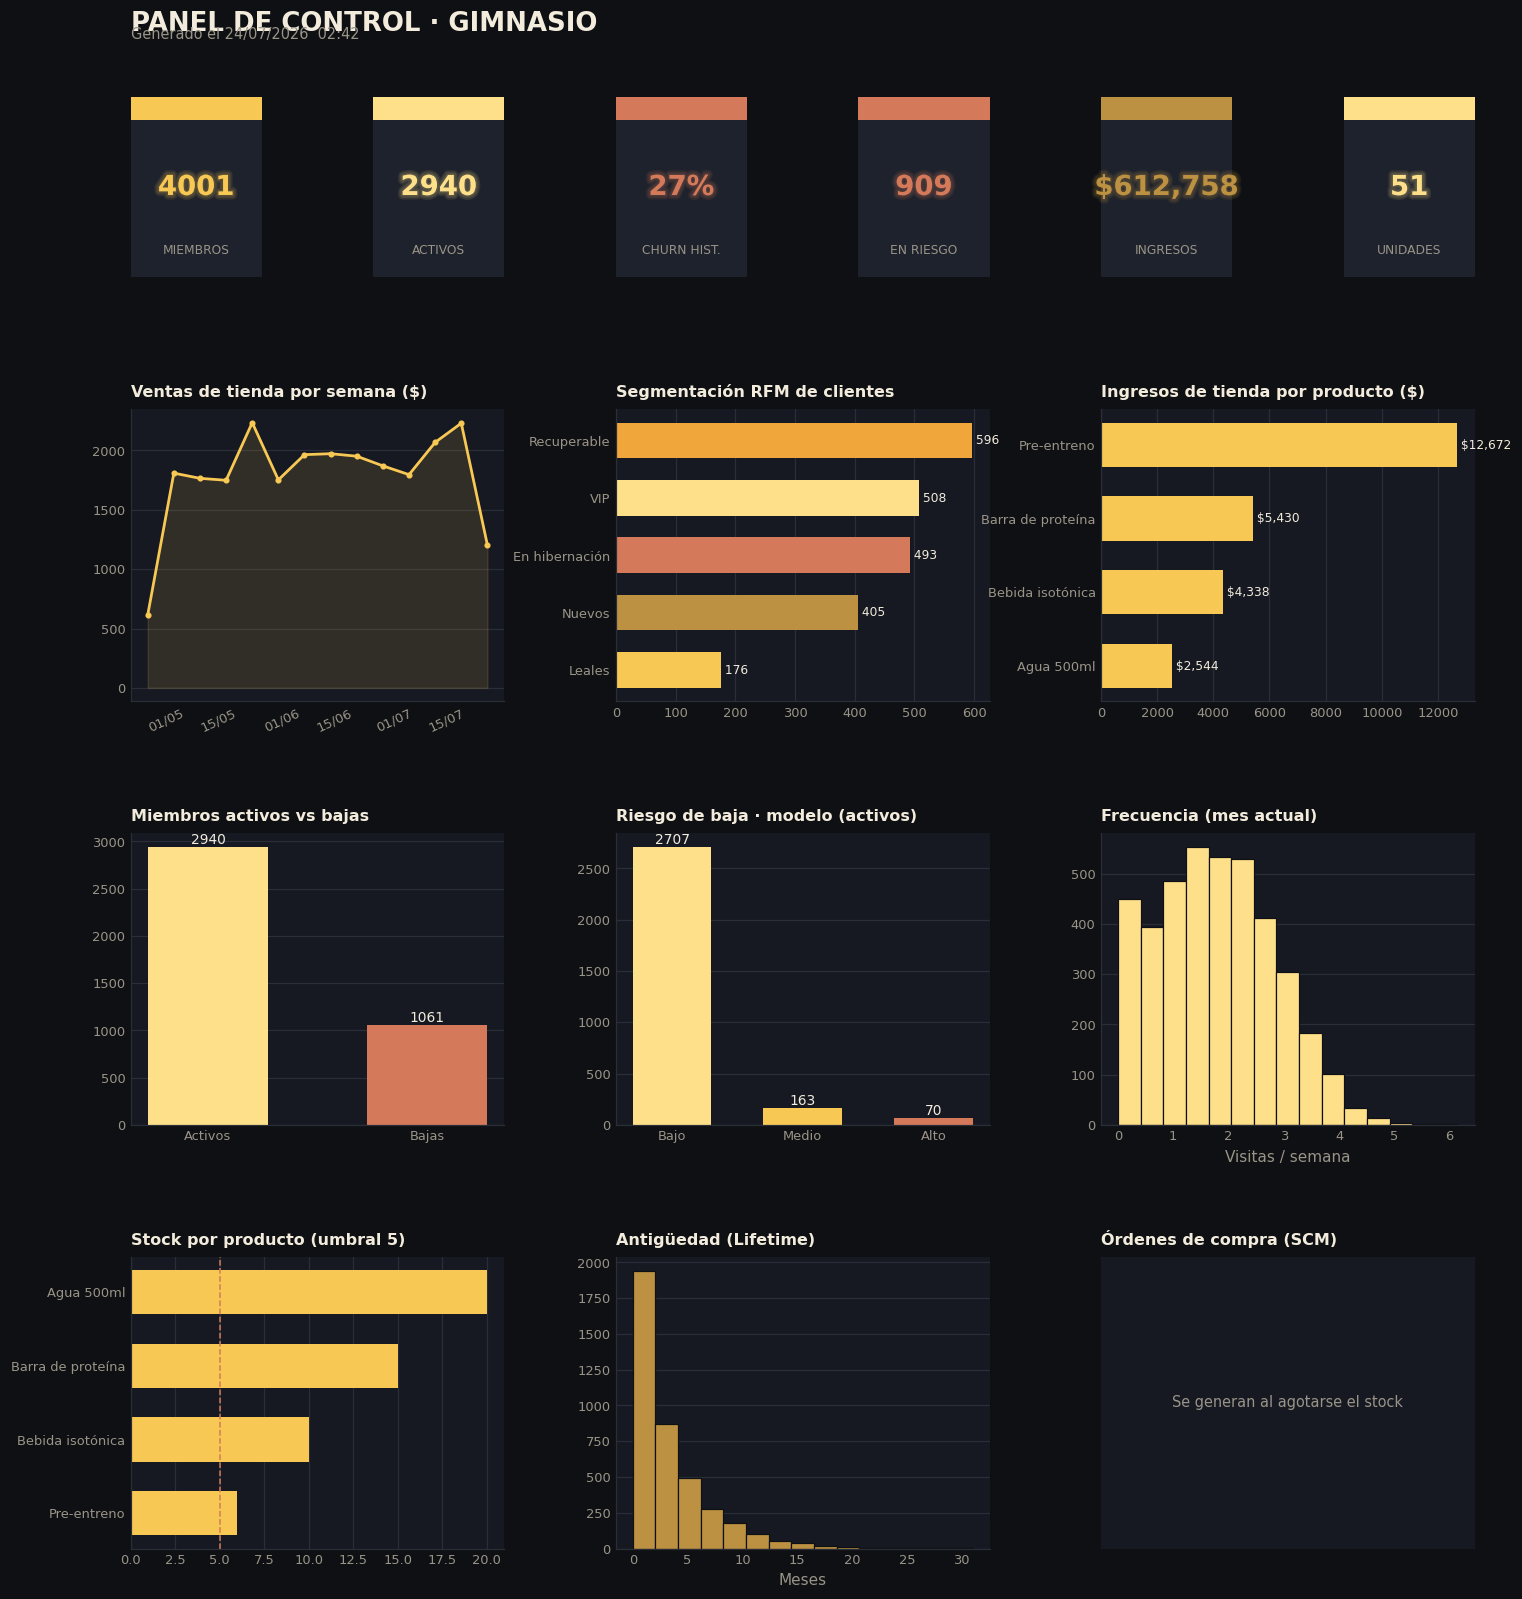

  · Dashboard generado (panel único).
  ✓ Datos guardados en los CSV. ¡Gracias por usar el Gestor!


In [28]:
def main():
    _aplicar_estilo_visual()
    _limpiar()
    _titulo("Stratify IA", doble=True)
    print("\n  Cargando datos del gimnasio...")
    gym = Gimnasio()
    gym.cargar()
    modelo_txt = "modelo predictivo activo" if gym.crm.modelo_ok else "modo heurístico"
    _ok(f"{len(gym.clientes)} miembros cargados · {modelo_txt}.")
    _info(f"Histórico de {len(gym.erp.transacciones)} transacciones · "
          f"{len(gym.scm.productos)} productos en inventario.")
    _pausa("Presiona Enter para comenzar...")

    while True:
        _limpiar()
        _regla("═")
        print("     STRATIFY IA")
        _regla("═")
        _item(1, "Administrador")
        _item(2, "Miembro / Cliente")
        _item(3, "Dashboard visual")
        _item(0, "Salir")
        op = _leer("\n  Opción > ").strip()
        if   op == "1": menu_admin(gym)
        elif op == "2": menu_miembro(gym)
        elif op == "3": mostrar_dashboard(gym, inline=False);  _pausa()
        elif op == "0":
            _limpiar()
            _titulo("Cerrando", doble=True)
            _info("Mostrando el dashboard final...")
            try:
                mostrar_dashboard(gym, inline=True)
            except Exception as e:
                _err(f"No se pudo generar el dashboard: {e}")
            _ok("Datos guardados en los CSV. ¡Gracias por usar el Gestor!")
            break
        else:
            _info("Opción no válida.");  _pausa()


if __name__ == "__main__":
    main()

## ▶ Ejecutar el gestor
Inicia el sistema. Se cargan los ~4000 miembros, se simula el histórico de transacciones (para RFM y la evolución temporal), se entrena el modelo del CRM y aparece el menú principal.


  CERRANDO
  ══════════════════════════════════════════════════════════
  · Mostrando el dashboard final...

  RESUMEN EJECUTIVO
  ══════════════════════════════════════════════════════════
  Miembros totales.............. 4001
  Activos / bajas............... 2940 / 1061
  Churn histórico............... 26.5%
  En riesgo (CRM, inactividad).. 909
  Ingresos en caja.............. $612,758.41
  Unidades en stock............. 51


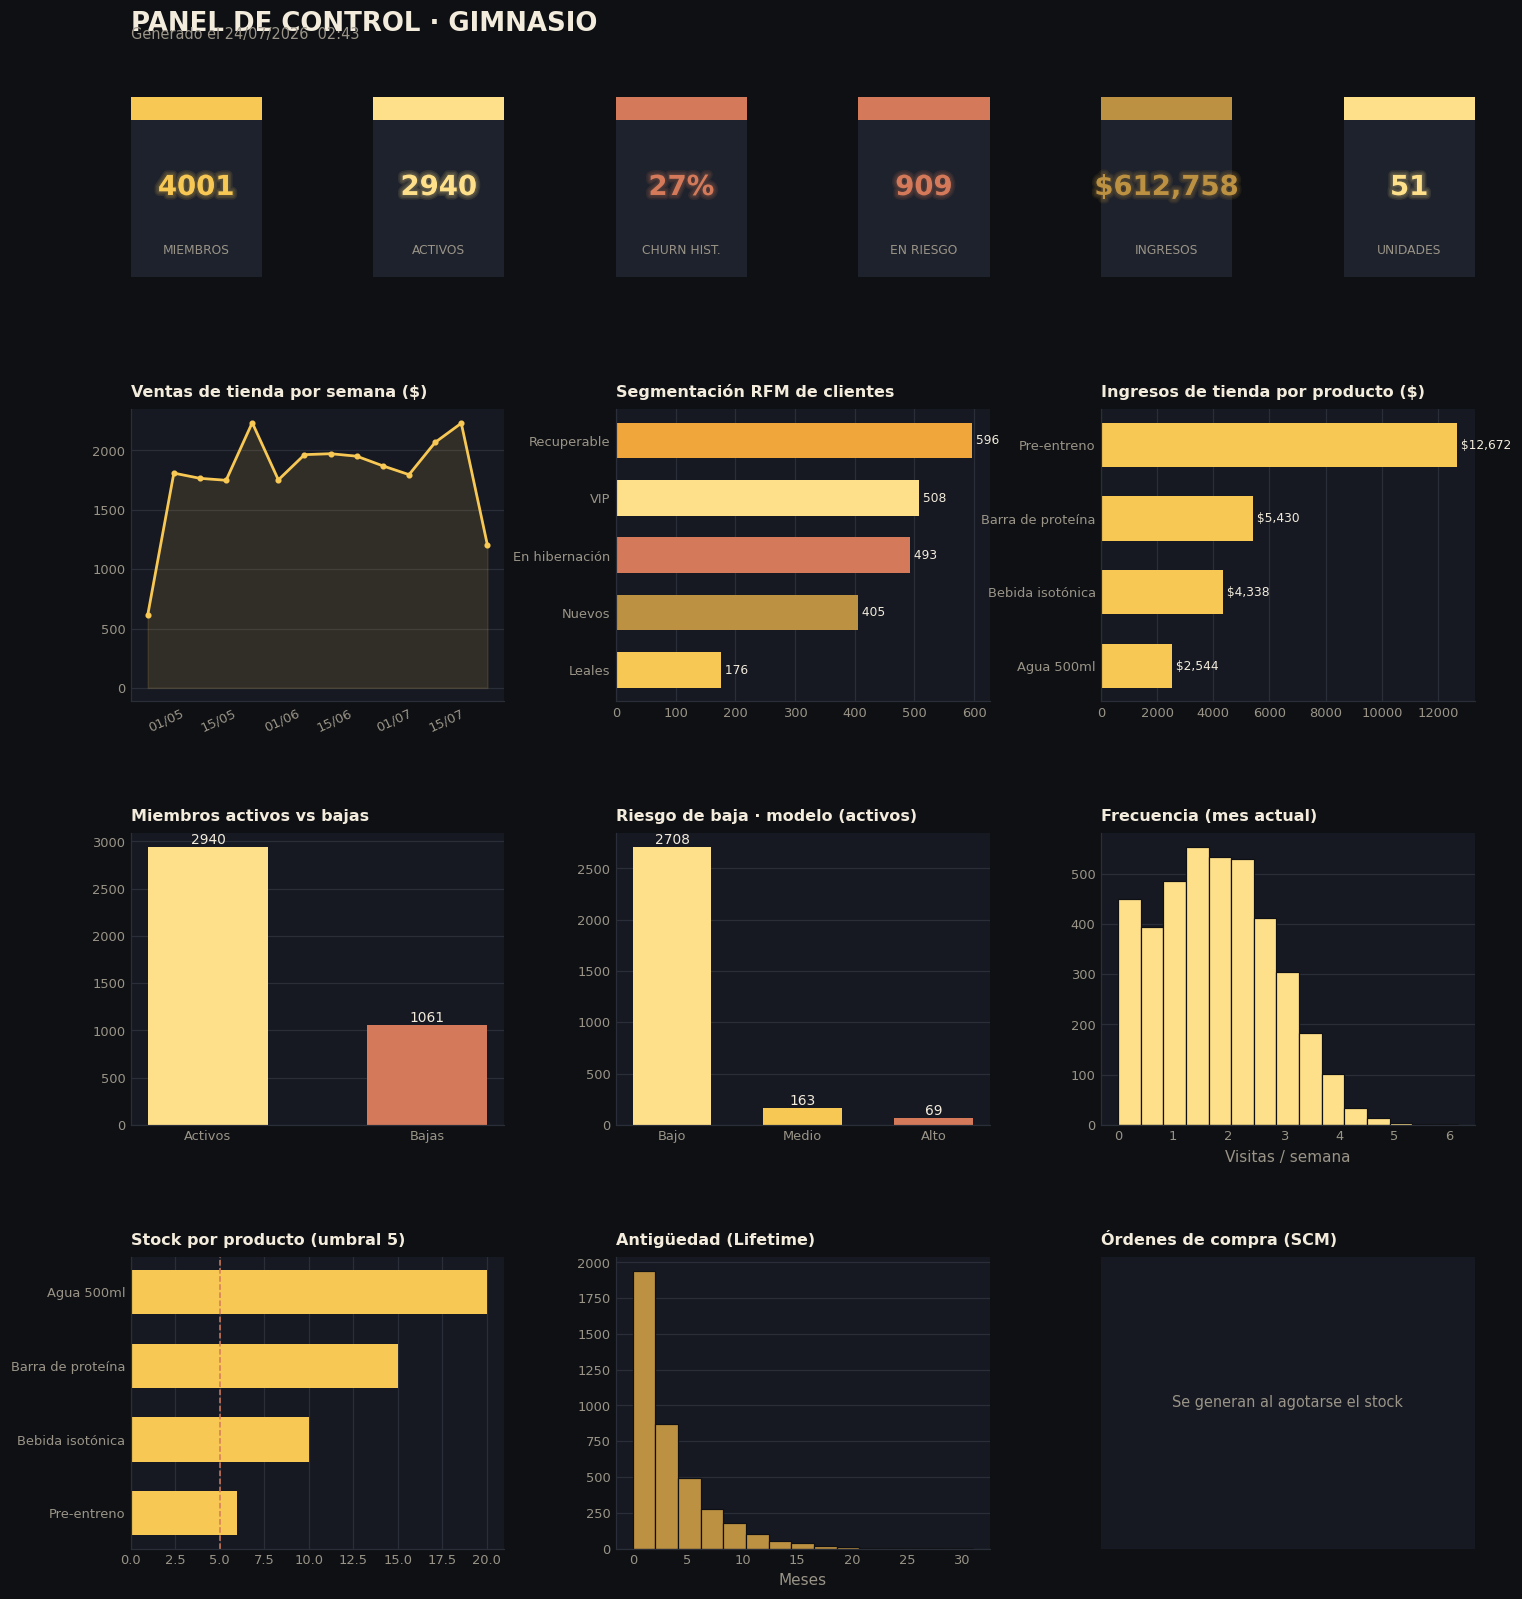

  · Dashboard generado (panel único).
  ✓ Datos guardados en los CSV. ¡Gracias por usar el Gestor!


In [29]:
main()

## 📊 (Opcional) Ver solo el dashboard
Genera el panel gerencial sin entrar a los menús.


  RESUMEN EJECUTIVO
  ══════════════════════════════════════════════════════════
  Miembros totales.............. 4001
  Activos / bajas............... 2940 / 1061
  Churn histórico............... 26.5%
  En riesgo (CRM, inactividad).. 909
  Ingresos en caja.............. $612,758.41
  Unidades en stock............. 51


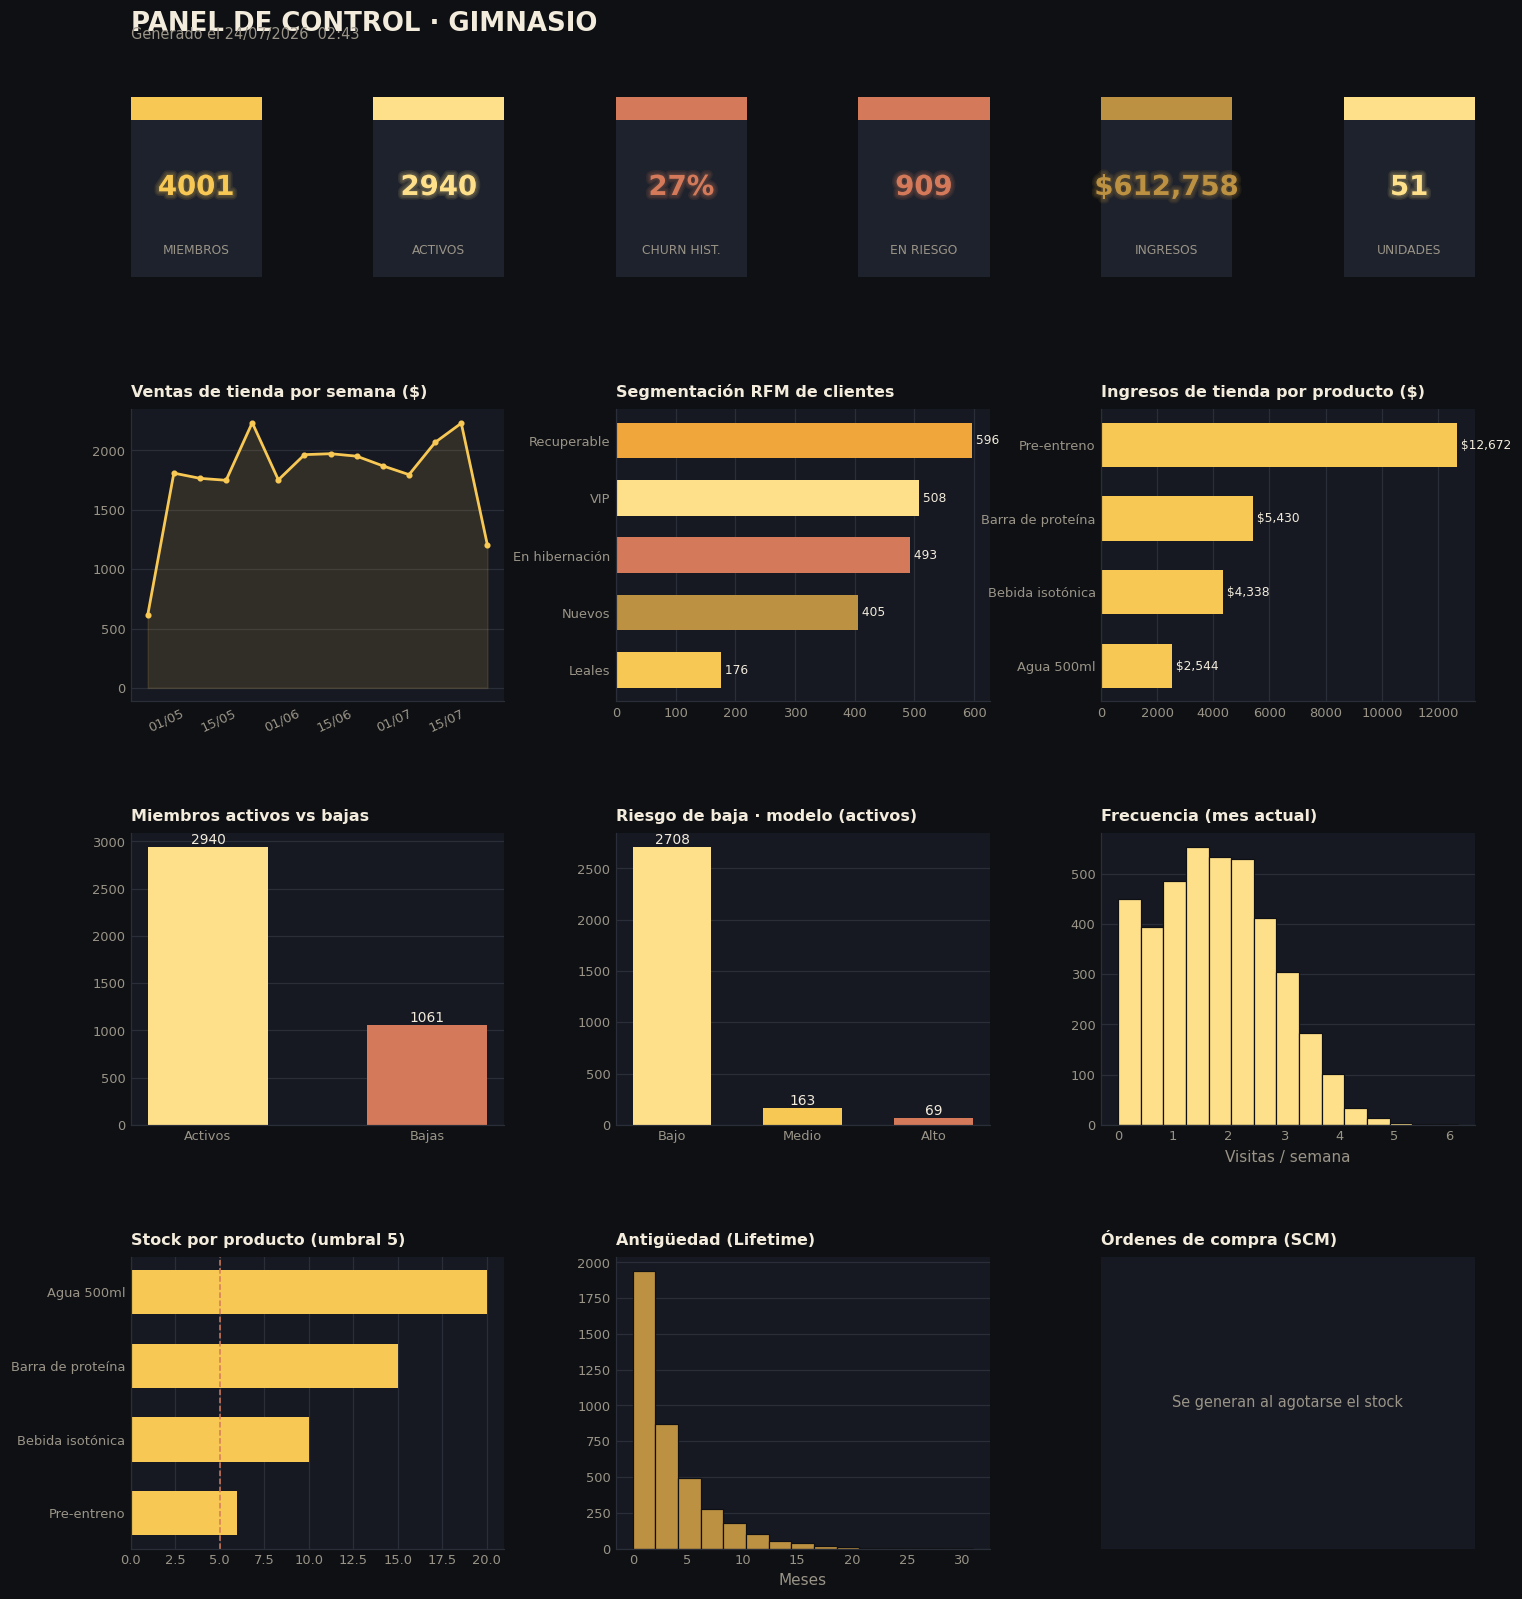

  · Dashboard generado (panel único).


In [30]:
gym = Gimnasio()
gym.cargar()
mostrar_dashboard(gym, inline=True)